# Ball Trajectory Prediction
## Prediksi Trajektori Bola Basket menggunakan Supervised Deep Learning
### Ujian Tengah Semester Genap TA 2025/2026 – Mata Kuliah Deep Learning

| Informasi | Detail |
|---|---|
| **Prodi / Kelas** | Magister Informatika / B |
| **Dosen Penguji** | Ir. Chandra Kusuma Dewa, S.Kom., M.Cs., Ph.D. |
| **Institusi** | Universitas Islam Indonesia |
| **Deadline** | 12 Juni 2026 (via Google Classroom) |
| **Mata Kuliah** | Deep Learning |
| **Nama** | Muhammad Dhiauddin |
| **NIM** | 25917024 |
| **Konsentrasi** | Sains Data - Profesional |
| **Github** | [https://github.com/Mudhya19/supervised-deep-learning.git](https://github.com/Mudhya19/supervised-deep-learning.git) |


---

### Deskripsi Notebook

Notebook ini adalah **implementasi end-to-end pipeline supervised deep learning** untuk
memprediksi trajektori bola basket di masa depan berdasarkan pola pergerakan pada
beberapa frame sebelumnya.  
Cakupan pipeline: unduh & potong video → YOLO tracking → CSV export → train/test split
→ sliding window → pelatihan tiga model (Simple RNN, LSTM, GRU) → evaluasi → komparasi.

### Struktur Notebook
| Bagian | Topik | Bobot |
|--------|-------|-------|
| 0 | Persiapan Dataset | – |
| 1 | Ekstraksi & Tracking Objek | 15 % |
| 2 | Data Engineering – CSV Exporter | 10 % |
| 3 | Data Engineering – Train/Test Split | 10 % |
| 4 | Data Engineering – Sliding Window | 15 % |
| 5 | Arsitektur Model | 20 % |
| 6 | Evaluasi Proses Training | 10 % |
| 7 | Pengujian & Komparasi Trajektori | 20 % |


## ⚙️ Setup Lingkungan & Global Imports

Blok ini mengimpor seluruh dependensi, mendefinisikan konfigurasi path proyek,
serta membuat direktori output yang diperlukan.  
Semua **konstanta konfigurasi** (hyperparameter, path, dll.) terpusat di sini
agar perubahan cukup dilakukan di satu tempat.


In [4]:
import sys
import subprocess
from pathlib import Path
import cv2
import warnings

# Mengatur BASE_DIR agar selalu menunjuk ke root proyek
_cwd = Path.cwd()
BASE_DIR = _cwd.parent if _cwd.name == 'notebooks' else _cwd

# ── Standar Library ───────────────────────────────────────────────────────────
import os, re, pickle
warnings.filterwarnings('ignore')

# ── Numerik & Data ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisasi ───────────────────────────────────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Computer Vision ───────────────────────────────────────────────────────────
import cv2
from IPython.display import display, Image as IPImage

# ── Deep Learning ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Preprocessing & Metrik ────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Device aktif  : {DEVICE}")
print(f"[INFO] PyTorch versi : {torch.__version__}")
print(f"[INFO] OpenCV  versi : {cv2.__version__}")
print(f"[INFO] Pandas  versi : {pd.__version__}")

# ── Path Proyek ───────────────────────────────────────────────────────────────

VIDEO_SRC  = BASE_DIR / 'docs' / '3 Basketball Bouncing.mp4'
VIDEO_3MIN = BASE_DIR / 'docs' / '3 Basketball Bouncing_3min.mp4'
CSV_OUT    = BASE_DIR / 'data' / 'raw' / 'dataset_koordinat_bola.csv'
TENSOR_DIR = BASE_DIR / 'data' / 'processed' / 'tensors'
MODEL_DIR  = BASE_DIR / 'models'
IMAGE_DIR  = BASE_DIR / 'images' / 'output'
SAMPLES_DIR= IMAGE_DIR / 'tracking_samples'
LOG_DIR    = BASE_DIR / 'logs'

LOSS_CURVE_PATH      = IMAGE_DIR / 'loss_curves.png'
TRAJ_COMPARISON_PATH = IMAGE_DIR / 'trajectory_comparison.png'
TRACKING_DEMO_PATH   = IMAGE_DIR / 'tracking_demo.mp4'

# ── Konfigurasi Global ────────────────────────────────────────────────────────
FEATURE_COLS  = ['x_center', 'y_center']   # fitur input model
TARGET_COLS   = ['x_center', 'y_center']   # output target model
TRAIN_RATIO   = 0.666                      # 2 menit pertama
WINDOW_SIZE   = 20                         # look-back window (frame)
BATCH_SIZE    = 64
HIDDEN_SIZE   = 64
NUM_LAYERS    = 2
DROPOUT_RATE  = 0.2
LEARNING_RATE = 1e-3
NUM_EPOCHS    = 100
VAL_RATIO     = 0.15
PATIENCE      = 15
YOLO_MODEL    = str(BASE_DIR / 'yolov8x.pt')
CONF_THRESH   = 0.35
BALL_CLASS_ID = 32     # COCO: sports ball
SAMPLE_FRAMES = 10     # jumlah frame contoh yang disimpan

# ── Buat Direktori Output ─────────────────────────────────────────────────────
for d in [CSV_OUT.parent, TENSOR_DIR, MODEL_DIR, SAMPLES_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("\n[INFO] Semua direktori output telah diverifikasi / dibuat.")
for label, p in [
    ("Data raw  ", CSV_OUT.parent),
    ("Tensors   ", TENSOR_DIR),
    ("Models    ", MODEL_DIR),
    ("Images    ", IMAGE_DIR),
    ("Logs      ", LOG_DIR),
]:
    print(f"       {label}: {p}")


[INFO] Device aktif  : cpu
[INFO] PyTorch versi : 2.12.0+cpu
[INFO] OpenCV  versi : 4.13.0
[INFO] Pandas  versi : 3.0.3

[INFO] Semua direktori output telah diverifikasi / dibuat.
       Data raw  : c:\Users\IT\data science\supervised deep learning\data\raw
       Tensors   : c:\Users\IT\data science\supervised deep learning\data\processed\tensors
       Models    : c:\Users\IT\data science\supervised deep learning\models
       Images    : c:\Users\IT\data science\supervised deep learning\images\output
       Logs      : c:\Users\IT\data science\supervised deep learning\logs


---
# Bagian 0 – Persiapan Dataset

## Tujuan Bagian
Tahap ini merupakan **pra-pemrosesan awal** yang berdiri mandiri sebelum pipeline utama.
Tujuannya adalah memastikan video sumber tersedia dalam bentuk yang siap digunakan
oleh proses tracking: terunduh, terpotong ke 3 menit, dan terverifikasi kualitasnya.

## Konsep Inti
Kualitas seluruh pipeline downstream – mulai dari tracking hingga prediksi – sangat
ditentukan oleh kualitas video input. Pemilihan **segmen tengah** video dilakukan karena:
- Segmen tengah paling representatif dari aktivitas aktif bola basket;
- Bagian awal/akhir sering berisi transisi atau segmen tanpa bola aktif;
- Konsistensi cahaya dan sudut kamera biasanya lebih stabil di segmen tengah.

## Alur Bagian 0
```
0.1 Unduh video dari YouTube  →  docs/3 Basketball Bouncing.mp4
0.2 Potong ke 3 menit tengah  →  docs/3 Basketball Bouncing_3min.mp4
0.3 Verifikasi properti video
0.4 Penjelasan posisi dalam pipeline
```


### 0.1 Unduh Video Sumber

**URL Sumber:** `https://www.youtube.com/watch?v=oWqwY1MLBck`  
**Alat:** `yt-dlp` (instal dengan `pip install yt-dlp`)  
**Output:** `docs/3 Basketball Bouncing.mp4`

Jika video sudah tersedia secara manual di folder `docs/`, sel ini akan dilewati otomatis.


In [5]:
# ── 0.1 Unduh Video Sumber ────────────────────────────────────────────────────
import sys
import imageio_ffmpeg

YOUTUBE_URL = "https://www.youtube.com/watch?v=oWqwY1MLBck"

if VIDEO_SRC.exists():
    size_mb = VIDEO_SRC.stat().st_size / (1024**2)
    print(f"[SKIP] Video sumber sudah ada: {VIDEO_SRC.name}  ({size_mb:.1f} MB)")
else:
    print(f"[INFO] Mengunduh video dari: {YOUTUBE_URL}")
    cmd = [
        sys.executable, "-m", "yt_dlp",
        "--ffmpeg-location", imageio_ffmpeg.get_ffmpeg_exe(),
        "--format", "bestvideo[ext=mp4]+bestaudio[ext=m4a]/best[ext=mp4]",
        "--merge-output-format", "mp4",
        "--output", str(VIDEO_SRC),
        YOUTUBE_URL,
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode == 0:
        size_mb = VIDEO_SRC.stat().st_size / (1024**2)
        print(f"[OK]  Video berhasil diunduh: {VIDEO_SRC.name}  ({size_mb:.1f} MB)")
    else:
        print("[ERROR] Gagal mengunduh. Output yt-dlp:")
        print(result.stderr[-1000:])


[INFO] Mengunduh video dari: https://www.youtube.com/watch?v=oWqwY1MLBck
[OK]  Video berhasil diunduh: 3 Basketball Bouncing.mp4  (132.3 MB)


### 0.2 Pemotongan Video Menjadi 3 Menit

Video dipotong menggunakan `ffmpeg` dengan mengambil segmen **tepat di tengah** video.
Titik awal dihitung sebagai `(total_durasi − 180) / 2` detik dari awal file,
sehingga selalu terpusat secara temporal.

**Input:** `docs/3 Basketball Bouncing.mp4`  
**Output:** `docs/3 Basketball Bouncing_3min.mp4`


In [6]:
# ── 0.2 Pemotongan Video ke 3 Menit ─────────────────────────────────────────
import imageio_ffmpeg

TARGET_SEC = 180   # 3 menit

if VIDEO_3MIN.exists():
    print(f"[SKIP] Video 3 menit sudah ada: {VIDEO_3MIN.name}")
else:
    if not VIDEO_SRC.exists():
        raise FileNotFoundError(
            f"Video sumber tidak ditemukan: {VIDEO_SRC}\n"
            "Jalankan sel 0.1 atau letakkan file secara manual di docs/."
        )

    cap = cv2.VideoCapture(str(VIDEO_SRC))
    fps_src = cap.get(cv2.CAP_PROP_FPS)
    n_fr    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    dur_src = n_fr / fps_src
    cap.release()

    print(f"[INFO] Durasi sumber  : {dur_src:.1f} s  ({dur_src/60:.2f} menit)")
    if dur_src < TARGET_SEC:
        raise ValueError(f"Durasi video ({dur_src:.1f} s) < target ({TARGET_SEC} s).")

    start_s = (dur_src - TARGET_SEC) / 2
    print(f"[INFO] Potong mulai   : {start_s:.1f} s  →  {start_s + TARGET_SEC:.1f} s")

    cmd_cut = [
        imageio_ffmpeg.get_ffmpeg_exe(), "-y",
        "-ss", str(start_s),
        "-i", str(VIDEO_SRC),
        "-t", str(TARGET_SEC),
        "-c:v", "libx264", "-preset", "fast",
        "-c:a", "aac",
        str(VIDEO_3MIN),
    ]
    res = subprocess.run(cmd_cut, capture_output=True, text=True)
    if res.returncode == 0:
        print(f"[OK]  Video 3 menit disimpan: {VIDEO_3MIN.name}")
    else:
        print("[ERROR] ffmpeg gagal:")
        print(res.stderr[-1000:])


[INFO] Durasi sumber  : 1200.1 s  (20.00 menit)
[INFO] Potong mulai   : 510.0 s  →  690.0 s
[OK]  Video 3 menit disimpan: 3 Basketball Bouncing_3min.mp4


### 0.3 Verifikasi Video 3 Menit

Sebelum melanjutkan ke tracking, properti video hasil pemotongan diverifikasi:
durasi aktual, resolusi, frame rate, dan total frame.


In [7]:
# ── 0.3 Verifikasi Video 3 Menit ─────────────────────────────────────────────
if not VIDEO_3MIN.exists():
    raise FileNotFoundError(f"Video 3 menit tidak ditemukan: {VIDEO_3MIN}")

cap_v = cv2.VideoCapture(str(VIDEO_3MIN))
FPS_VID   = cap_v.get(cv2.CAP_PROP_FPS)
N_FRAMES  = int(cap_v.get(cv2.CAP_PROP_FRAME_COUNT))
VID_W     = int(cap_v.get(cv2.CAP_PROP_FRAME_WIDTH))
VID_H     = int(cap_v.get(cv2.CAP_PROP_FRAME_HEIGHT))
DURATION  = N_FRAMES / FPS_VID
cap_v.release()

print("=" * 52)
print("   RINGKASAN VIDEO 3 MENIT")
print("=" * 52)
print(f"  File        : {VIDEO_3MIN.name}")
print(f"  Resolusi    : {VID_W} × {VID_H} piksel")
print(f"  Frame Rate  : {FPS_VID:.2f} FPS")
print(f"  Total Frame : {N_FRAMES:,}")
print(f"  Durasi      : {DURATION:.2f} s  ({DURATION/60:.2f} menit)")
print(f"  Ukuran      : {VIDEO_3MIN.stat().st_size/(1024**2):.2f} MB")
print("=" * 52)

status = "[OK]" if abs(DURATION - 180) <= 5 else "[WARN]"
print(f"{status} Durasi {'sesuai' if status == '[OK]' else 'menyimpang dari'} target 180 s.")

# Simpan metadata ke log
log_meta = LOG_DIR / 'video_metadata.txt'
log_meta.write_text(
    f"fps={FPS_VID}\ntotal_frames={N_FRAMES}\n"
    f"width={VID_W}\nheight={VID_H}\nduration_sec={DURATION:.2f}\n"
)
print(f"[INFO] Metadata disimpan: {log_meta}")


   RINGKASAN VIDEO 3 MENIT
  File        : 3 Basketball Bouncing_3min.mp4
  Resolusi    : 1280 × 720 piksel
  Frame Rate  : 30.00 FPS
  Total Frame : 5,399
  Durasi      : 179.97 s  (3.00 menit)
  Ukuran      : 20.15 MB
[OK] Durasi sesuai target 180 s.
[INFO] Metadata disimpan: c:\Users\IT\data science\supervised deep learning\logs\video_metadata.txt


### 0.4 Posisi Bagian 0 dalam Pipeline

Bagian 0 adalah **tahap pra-pemrosesan yang independen** – ia mempersiapkan artefak
video sebagai prasyarat, bukan bagian dari tracking itu sendiri.

```
[0] Persiapan Dataset          
     ↓
[1] Ekstraksi & Tracking Objek
     ↓
[2] Data Engineering – CSV Exporter
     ↓
[3] Data Engineering – Train/Test Split
     ↓
[4] Data Engineering – Sliding Window
     ↓
[5] Arsitektur Model
     ↓
[6] Evaluasi Proses Training
     ↓
[7] Pengujian & Komparasi Trajektori
```

Dengan selesainya Bagian 0, dua prasyarat dijamin terpenuhi:
- `docs/3 Basketball Bouncing.mp4` – video sumber tersedia
- `docs/3 Basketball Bouncing_3min.mp4` – video 3 menit siap digunakan


---
# Soal 1 – Ekstraksi & Tracking Objek (15 %)

## 1.1 Latar Belakang

Tahap pertama pipeline ini bertujuan **memperoleh koordinat posisi bola basket
secara temporal dari video** menggunakan pendekatan *object detection* yang
diintegrasikan dengan *multi-object tracking*.

### Konsep Inti: YOLO Tracking

**YOLO (You Only Look Once)** adalah arsitektur *single-stage object detector* yang
dikenal karena kecepatan inferensinya. YOLOv8 dari Ultralytics menyediakan API
`model.track()` yang menggabungkan deteksi dengan algoritma pelacak (ByteTrack/BoT-SORT),
sehingga setiap objek yang terdeteksi mendapat **ID unik yang konsisten antar frame**.

Properti yang sangat krusial untuk tugas ini karena:
1. Terdapat **tiga bola basket** yang harus dilacak secara simultan;
2. Setiap bola harus memiliki **identitas stabil** agar trajektorinya dapat dipelajari
   sebagai sekuens temporal yang koheren;
3. *ID switching* harus diminimalkan demi integritas data.

### Parameter Model
- Model: `yolov8x.pt` (extra large) – akurasi sangat tinggi (mengambil dari root folder)
- Class ID COCO untuk *sports ball*: `32`
- Confidence threshold: `0.35`

**Input:**  `docs/3 Basketball Bouncing_3min.mp4`  
**Output:**  
- `images/output/tracking_demo.mp4`  
- `images/output/tracking_samples/frame_*.jpg`  
- Data koordinat mentah (diteruskan ke Bagian 2)


### 1.2 Import dan Inisialisasi Model YOLO


In [8]:
# ── 1.2 Import & Inisialisasi YOLO ───────────────────────────────────────────
from ultralytics import YOLO

print(f"[INFO] Memuat model YOLO : {YOLO_MODEL}")
yolo_model = YOLO(YOLO_MODEL)
print("[OK]  Model YOLO berhasil dimuat.")
print(f"[INFO] Confidence threshold : {CONF_THRESH}")
print(f"[INFO] Class ID bola        : {BALL_CLASS_ID}  (COCO: sports ball)")


[INFO] Memuat model YOLO : c:\Users\IT\data science\supervised deep learning\yolov8x.pt
[OK]  Model YOLO berhasil dimuat.
[INFO] Confidence threshold : 0.35
[INFO] Class ID bola        : 32  (COCO: sports ball)


### 1.3 Implementasi YOLO Tracking (`model.track()`)

`model.track()` dijalankan dengan `stream=True` (hemat memori) dan `persist=True`
(ID konsisten antar frame). Setiap frame yang berhasil mendeteksi bola akan
menghasilkan bounding box, track ID, dan confidence score.

Secara bersamaan proses ini:
1. Menulis setiap frame yang dianotasi ke `tracking_demo.mp4`;
2. Menyimpan `SAMPLE_FRAMES` frame contoh ke `tracking_samples/`;
3. Mengumpulkan data koordinat ke list `raw_tracking_data`.


In [9]:
# ── 1.3 YOLO Tracking – Loop Utama ───────────────────────────────────────────
if not VIDEO_3MIN.exists():
    raise FileNotFoundError(f"Video tidak ditemukan: {VIDEO_3MIN}")

# Ambil properti video (gunakan nilai dari Bagian 0 jika sudah ada)
try:
    _fps = FPS_VID; _nfr = N_FRAMES; _w = VID_W; _h = VID_H
except NameError:
    _cap = cv2.VideoCapture(str(VIDEO_3MIN))
    _fps = _cap.get(cv2.CAP_PROP_FPS)
    _nfr = int(_cap.get(cv2.CAP_PROP_FRAME_COUNT))
    _w   = int(_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    _h   = int(_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    _cap.release()

print(f"[INFO] Video: {_nfr:,} frame | {_fps:.1f} FPS | {_w}×{_h} px")

# VideoWriter untuk demo
fourcc   = cv2.VideoWriter_fourcc(*'mp4v')
out_demo = cv2.VideoWriter(str(TRACKING_DEMO_PATH), fourcc, _fps, (_w, _h))

# Interval sampling frame contoh
sample_interval = max(1, _nfr // SAMPLE_FRAMES)

raw_tracking_data = []
frame_id     = 0
sample_count = 0

print("[INFO] Memulai tracking … (estimasi beberapa menit bergantung GPU/CPU)")

for result in yolo_model.track(
        source   = str(VIDEO_3MIN),
        stream   = True,
        persist  = True,
        conf     = CONF_THRESH,
        classes  = [BALL_CLASS_ID],
        verbose  = False):

    frame_ann = result.plot()
    out_demo.write(frame_ann)

    # Simpan sample frame
    if frame_id % sample_interval == 0 and sample_count < SAMPLE_FRAMES:
        sp = SAMPLES_DIR / f"frame_{frame_id:06d}.jpg"
        cv2.imwrite(str(sp), frame_ann)
        sample_count += 1

    # Ekstrak koordinat
    boxes = result.boxes
    if boxes is not None and boxes.id is not None:
        xywh_arr  = boxes.xywh.cpu().numpy()
        track_ids = boxes.id.int().cpu().numpy()
        conf_arr  = boxes.conf.cpu().numpy()
        for (xc, yc, bw, bh), tid, cf in zip(xywh_arr, track_ids, conf_arr):
            raw_tracking_data.append({
                'frame'      : frame_id,
                'ball_id'    : int(tid),
                'x_center'   : float(xc),
                'y_center'   : float(yc),
                'width'      : float(bw),
                'height'     : float(bh),
                'confidence' : float(cf),
            })

    frame_id += 1
    if frame_id % 500 == 0:
        print(f"   [PROGRESS] {frame_id:,} / {_nfr:,} frame diproses …")

out_demo.release()
print(f"\n[OK]  Tracking selesai. Total frame: {frame_id:,}")
print(f"[OK]  Video demo disimpan  : {TRACKING_DEMO_PATH.name}")
print(f"[OK]  {sample_count} sample frame disimpan di {SAMPLES_DIR.name}/")
print(f"[INFO] Total deteksi terkumpul: {len(raw_tracking_data):,}")


[INFO] Video: 5,399 frame | 30.0 FPS | 1280×720 px
[INFO] Memulai tracking … (estimasi beberapa menit bergantung GPU/CPU)
   [PROGRESS] 500 / 5,399 frame diproses …
   [PROGRESS] 1,000 / 5,399 frame diproses …
   [PROGRESS] 1,500 / 5,399 frame diproses …
   [PROGRESS] 2,000 / 5,399 frame diproses …
   [PROGRESS] 2,500 / 5,399 frame diproses …
   [PROGRESS] 3,000 / 5,399 frame diproses …
   [PROGRESS] 3,500 / 5,399 frame diproses …
   [PROGRESS] 4,000 / 5,399 frame diproses …
   [PROGRESS] 4,500 / 5,399 frame diproses …
   [PROGRESS] 5,000 / 5,399 frame diproses …

[OK]  Tracking selesai. Total frame: 5,399
[OK]  Video demo disimpan  : tracking_demo.mp4
[OK]  10 sample frame disimpan di tracking_samples/
[INFO] Total deteksi terkumpul: 11,526


### 1.4 Validasi Hasil Tracking

Validasi visual dan statistik memastikan kualitas data tracking sebelum dilanjutkan.
Aspek yang diperiksa: jumlah ID unik, distribusi deteksi per ball, dan preview frame.


   RINGKASAN HASIL TRACKING
  Total deteksi     : 11,526
  Frame unik        : 5,344
  ID bola terdeteksi: [np.int64(1), np.int64(2), np.int64(3), np.int64(6), np.int64(7), np.int64(12), np.int64(15), np.int64(21), np.int64(22), np.int64(28), np.int64(29), np.int64(33), np.int64(39), np.int64(44), np.int64(50), np.int64(53), np.int64(54), np.int64(57), np.int64(59), np.int64(63), np.int64(69), np.int64(73), np.int64(74), np.int64(77), np.int64(80), np.int64(83), np.int64(88), np.int64(93), np.int64(99), np.int64(103), np.int64(114), np.int64(115), np.int64(116), np.int64(120), np.int64(125), np.int64(131), np.int64(132), np.int64(135), np.int64(137), np.int64(143), np.int64(148), np.int64(154), np.int64(155), np.int64(159), np.int64(160), np.int64(170), np.int64(171), np.int64(172), np.int64(173), np.int64(178), np.int64(185), np.int64(189), np.int64(190), np.int64(197), np.int64(201), np.int64(202), np.int64(207), np.int64(208), np.int64(210), np.int64(213), np.int64(214), np.int64(21

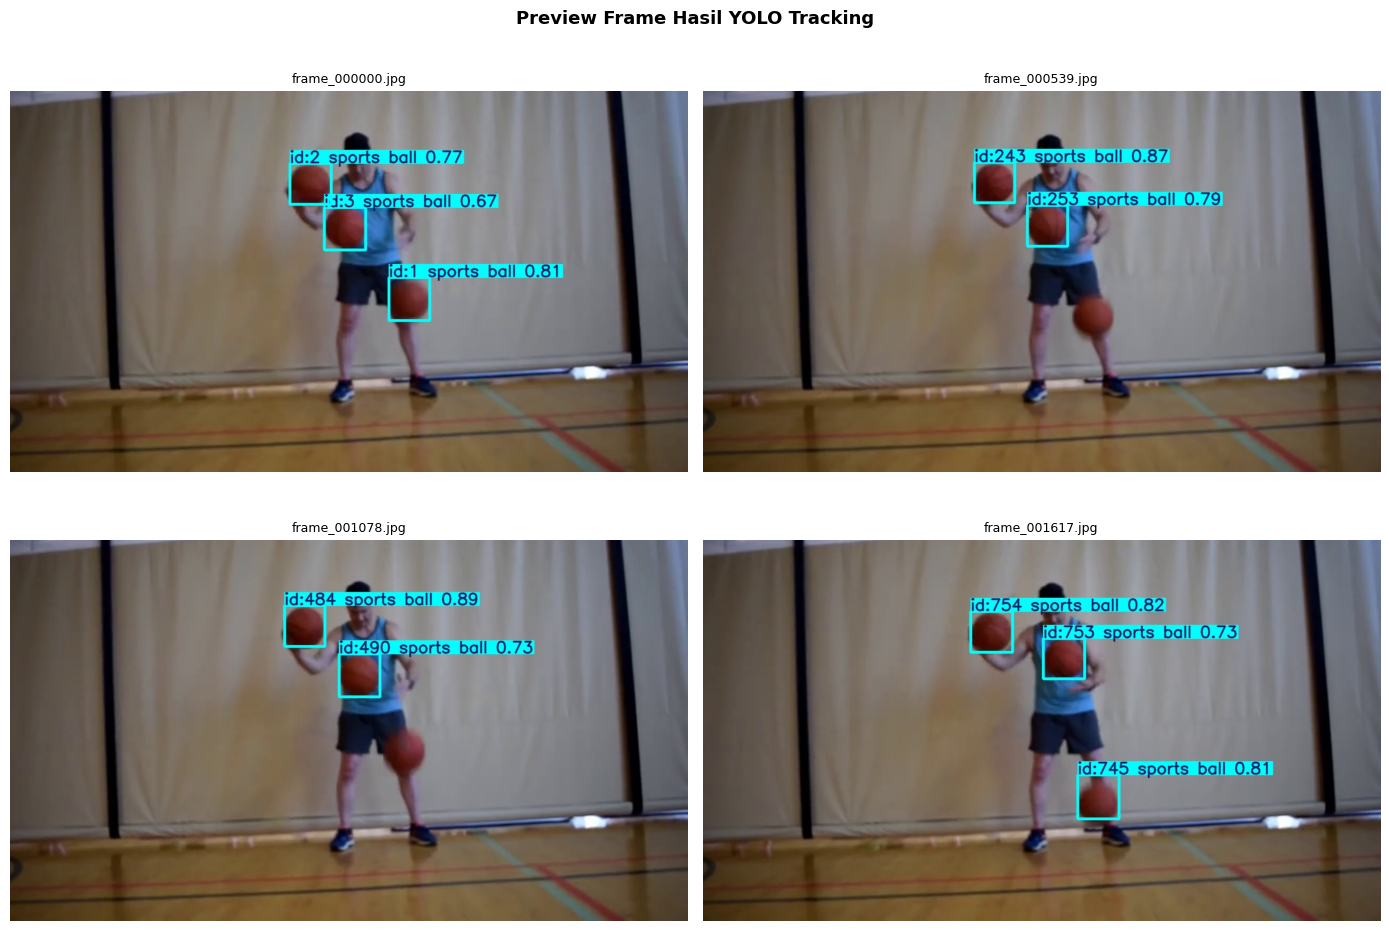

[OK]  Preview tersimpan.


In [10]:
# ── 1.4 Validasi Hasil Tracking ──────────────────────────────────────────────
df_raw = pd.DataFrame(raw_tracking_data)

print("=" * 58)
print("   RINGKASAN HASIL TRACKING")
print("=" * 58)
print(f"  Total deteksi     : {len(df_raw):,}")
print(f"  Frame unik        : {df_raw['frame'].nunique():,}")
print(f"  ID bola terdeteksi: {sorted(df_raw['ball_id'].unique())}")
print()
summary = df_raw.groupby('ball_id').agg(
    n_deteksi    = ('frame', 'count'),
    frame_awal   = ('frame', 'min'),
    frame_akhir  = ('frame', 'max'),
    conf_mean    = ('confidence', 'mean'),
).round(3)
print(summary.to_string())
print("=" * 58)
if df_raw['ball_id'].nunique() < 3:
    print("[WARN] Kurang dari 3 ID terdeteksi – periksa CONF_THRESH atau model YOLO.")
else:
    print("[OK]  Tiga bola berhasil dilacak.")

# Preview sample frame
sample_imgs = sorted(SAMPLES_DIR.glob("*.jpg"))[:4]
if sample_imgs:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes_flat = axes.flatten()
    for i, ax in enumerate(axes_flat):
        if i < len(sample_imgs):
            p = sample_imgs[i]
            img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
            ax.imshow(img); ax.set_title(p.name, fontsize=9)
        ax.axis('off')
    plt.suptitle("Preview Frame Hasil YOLO Tracking", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(IMAGE_DIR / 'tracking_preview.png'), dpi=100, bbox_inches='tight')
    plt.show()
    print("[OK]  Preview tersimpan.")


---
# Soal 2 – Data Engineering: CSV Exporter (10 %)

## 2.1 Struktur Dataset Koordinat

Tahap ini mengubah data tracking mentah menjadi **dataset tabular terstruktur**.
Semua bola disimpan dalam **satu file CSV terpadu** (bukan dipisah per bola)
untuk memudahkan filtrasi per `ball_id` dan pemrosesan seragam di tahap berikutnya.

| Kolom | Tipe | Keterangan |
|-------|------|-----------|
| `frame` | int | Nomor frame – merepresentasikan urutan temporal |
| `ball_id` | int | ID unik bola hasil YOLO tracking |
| `x_center` | float | Koordinat X titik tengah bounding box (piksel) |
| `y_center` | float | Koordinat Y titik tengah bounding box (piksel) |
| `confidence` | float | Skor kepercayaan deteksi (0–1) |

**Input:** `raw_tracking_data` (dari Bagian 1)  
**Output:** `data/raw/dataset_koordinat_bola.csv`


In [11]:
# ── 2.1 Konsolidasi Dataset ───────────────────────────────────────────────────
# Gunakan data dari memori; fallback ke CSV jika tidak ada
if 'df_raw' not in dir() or df_raw.empty:
    if CSV_OUT.exists():
        print(f"[INFO] Memuat ulang dari: {CSV_OUT}")
        df_raw = pd.read_csv(CSV_OUT)
    else:
        raise RuntimeError("Jalankan Bagian 1 terlebih dahulu.")

cols = ['frame', 'ball_id', 'x_center', 'y_center', 'confidence']
df_export = (df_raw[cols].copy()
               .sort_values(['frame', 'ball_id'])
               .reset_index(drop=True))

# Bulatkan float
for c in ['x_center', 'y_center', 'confidence']:
    df_export[c] = df_export[c].round(4)

print("Contoh 10 baris pertama:")
print(df_export.head(10).to_string(index=False))
print(f"\nBentuk DataFrame: {df_export.shape}")


Contoh 10 baris pertama:
 frame  ball_id  x_center  y_center  confidence
     0        1  754.0781  394.1630      0.8107
     0        2  567.6678  177.2509      0.7741
     0        3  632.4658  261.5830      0.6723
     1        1  750.9674  431.5366      0.7706
     1        2  559.1179  173.0746      0.8342
     1        3  634.8121  249.5472      0.7525
     2        1  748.9286  476.5821      0.8461
     2        2  551.5444  169.9999      0.8613
     2        3  637.7533  238.6976      0.7840
     3        1  745.1909  528.5771      0.8708

Bentuk DataFrame: (11526, 5)


### 2.2 Konsolidasi Tiga Bola dalam Satu DataFrame

Penyimpanan ketiga bola dalam satu file memberikan keunggulan:
- **Efisiensi** – satu file vs. tiga file terpisah
- **Fleksibilitas** – filter mudah via `df[df['ball_id'] == N]`
- **Kemudahan engineering** – normalisasi dan sliding window diterapkan seragam


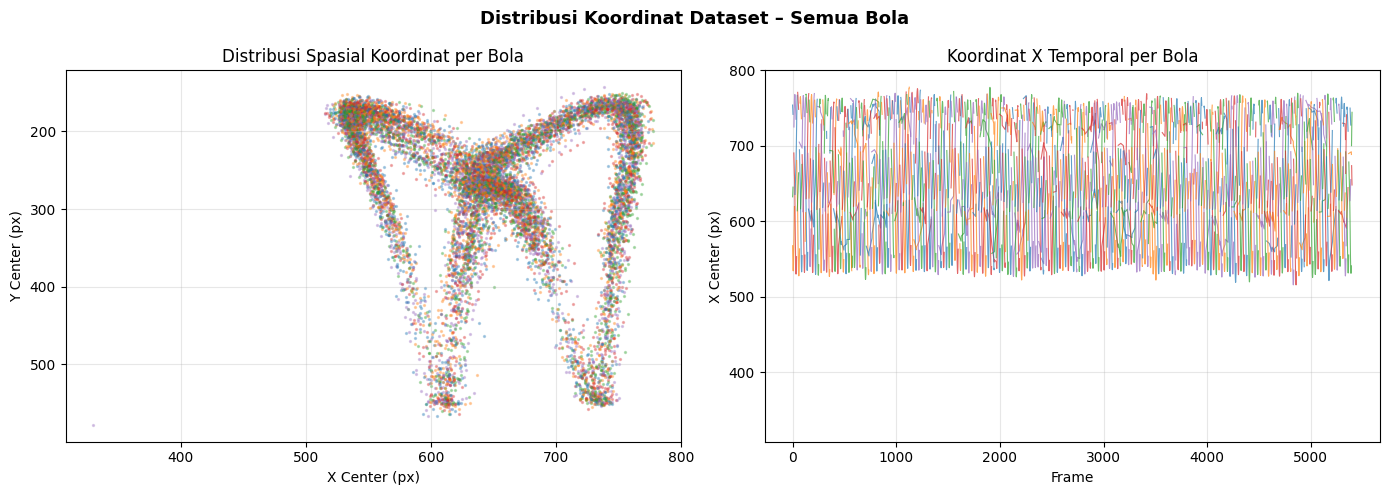


Statistik per Ball ID:
        x_center                                                         \
           count    mean    std     min     25%     50%     75%     max   
ball_id                                                                   
1            5.0  748.19   4.82  741.77  745.19  748.93  750.97  754.08   
2           19.0  563.98  26.56  534.35  541.99  559.12  580.35  619.62   
3            5.0  638.39   5.16  632.47  634.81  637.75  641.63  645.29   
6           26.0  601.20  59.47  530.03  543.26  594.22  659.03  690.59   
7           16.0  753.11  12.30  725.02  746.73  754.90  762.13  768.12   
...          ...     ...    ...     ...     ...     ...     ...     ...   
2615         9.0  640.54   9.61  627.46  633.49  640.10  647.61  655.31   
2617         8.0  738.08   7.94  727.56  732.25  738.05  743.39  750.09   
2620         1.0  708.10    NaN  708.10  708.10  708.10  708.10  708.10   
2623         6.0  723.31  16.79  700.22  711.88  724.60  734.88  744.48   
2

In [12]:
# ── 2.2 Analisis Distribusi per Ball ID ──────────────────────────────────────
colors_ball = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
ball_ids_all = sorted(df_export['ball_id'].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, bid in enumerate(ball_ids_all):
    sub = df_export[df_export['ball_id'] == bid]
    c   = colors_ball[i % len(colors_ball)]
    axes[0].scatter(sub['x_center'], sub['y_center'],
                    s=2, alpha=0.3, c=c, label=f'Ball {bid}')
    axes[1].plot(sub['frame'], sub['x_center'],
                 lw=0.8, alpha=0.7, c=c, label=f'Ball {bid}')

axes[0].set_title('Distribusi Spasial Koordinat per Bola')
axes[0].set_xlabel('X Center (px)'); axes[0].set_ylabel('Y Center (px)')
axes[0].invert_yaxis(); axes[0].grid(alpha=0.3)

axes[1].set_title('Koordinat X Temporal per Bola')
axes[1].set_xlabel('Frame'); axes[1].set_ylabel('X Center (px)')
axes[1].grid(alpha=0.3)

plt.suptitle('Distribusi Koordinat Dataset – Semua Bola', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(IMAGE_DIR / 'coord_distribution.png'), dpi=100, bbox_inches='tight')
plt.show()

# Statistik ringkas
print("\nStatistik per Ball ID:")
print(df_export.groupby('ball_id')[['x_center','y_center','confidence']].describe().round(2))


### 2.3 Penyimpanan ke CSV

File CSV ini menjadi **satu-satunya input** untuk Bagian 3–7, sehingga pipeline
dapat dijalankan ulang dari Bagian 3 tanpa mengulang tracking.


In [13]:
# ── 2.3 Simpan CSV ────────────────────────────────────────────────────────────
df_export.to_csv(str(CSV_OUT), index=False)
print(f"[OK]  Dataset disimpan : {CSV_OUT}")
print(f"       Ukuran  : {CSV_OUT.stat().st_size/1024:.2f} KB")
print(f"       Baris   : {len(df_export):,}")
print(f"       Kolom   : {list(df_export.columns)}")


[OK]  Dataset disimpan : c:\Users\IT\data science\supervised deep learning\data\raw\dataset_koordinat_bola.csv
       Ukuran  : 394.14 KB
       Baris   : 11,526
       Kolom   : ['frame', 'ball_id', 'x_center', 'y_center', 'confidence']


### 2.4 Pemeriksaan Kualitas Data

Pemeriksaan meliputi: missing values, jumlah ID unik, coverage frame, dan
koordinat *out-of-bounds*.


In [14]:
# ── 2.4 Quality Check ────────────────────────────────────────────────────────
print("=" * 58)
print("   PEMERIKSAAN KUALITAS DATA")
print("=" * 58)

# Missing values
print("\n[1] Missing Values:")
print(df_export.isnull().sum().to_string())

# ID unik
print(f"\n[2] Ball ID Unik: {sorted(df_export['ball_id'].unique())}")
n_id = df_export['ball_id'].nunique()
print(f"     {'[OK]' if n_id == 3 else '[WARN]'} {n_id} ID terdeteksi (diharapkan 3).")

# Coverage frame
fr_max      = df_export['frame'].max()
fr_detected = set(df_export['frame'].unique())
fr_all      = set(range(fr_max + 1))
fr_missing  = fr_all - fr_detected
cov_pct     = len(fr_detected) / len(fr_all) * 100
print(f"\n[3] Coverage Frame: {cov_pct:.1f}% "
      f"({len(fr_detected):,} / {len(fr_all):,} frame)")
if fr_missing:
    print(f"     Frame tanpa deteksi: {len(fr_missing):,}  "
          f"(contoh: {sorted(fr_missing)[:5]})")

# Out-of-bounds
try:
    W_v, H_v = VID_W, VID_H
except NameError:
    W_v, H_v = 1920, 1080
oob = ((df_export['x_center'] < 0) | (df_export['x_center'] > W_v) |
       (df_export['y_center'] < 0) | (df_export['y_center'] > H_v)).sum()
print(f"\n[4] Koordinat out-of-bounds: {oob}")

print("\n[INFO] Pemeriksaan kualitas selesai.")


   PEMERIKSAAN KUALITAS DATA

[1] Missing Values:
frame         0
ball_id       0
x_center      0
y_center      0
confidence    0

[2] Ball ID Unik: [np.int64(1), np.int64(2), np.int64(3), np.int64(6), np.int64(7), np.int64(12), np.int64(15), np.int64(21), np.int64(22), np.int64(28), np.int64(29), np.int64(33), np.int64(39), np.int64(44), np.int64(50), np.int64(53), np.int64(54), np.int64(57), np.int64(59), np.int64(63), np.int64(69), np.int64(73), np.int64(74), np.int64(77), np.int64(80), np.int64(83), np.int64(88), np.int64(93), np.int64(99), np.int64(103), np.int64(114), np.int64(115), np.int64(116), np.int64(120), np.int64(125), np.int64(131), np.int64(132), np.int64(135), np.int64(137), np.int64(143), np.int64(148), np.int64(154), np.int64(155), np.int64(159), np.int64(160), np.int64(170), np.int64(171), np.int64(172), np.int64(173), np.int64(178), np.int64(185), np.int64(189), np.int64(190), np.int64(197), np.int64(201), np.int64(202), np.int64(207), np.int64(208), np.int64(210),

---
# Soal 3 – Data Engineering: Train/Test Split (10 %)

## 3.1 Prinsip Split Kronologis

> **Mengapa tidak boleh random split?**

Prediksi trajektori adalah masalah *time series forecasting*. Random split akan
menciptakan **data leakage** – model akan "melihat" data dari masa depan selama
training, menghasilkan evaluasi yang tidak valid secara ilmiah.

Pembagian harus **kronologis**: data yang lebih awal → train, data yang lebih
lambat → test.

### Skema Split (sesuai instruksi soal)
| Partisi | Proporsi | Deskripsi |
|---------|----------|-----------|
| **Train** | 66.6 % (2 menit pertama) | Model belajar dari masa lalu |
| **Test**  | 33.3 % (1 menit terakhir) | Evaluasi pada masa depan |

Split dilakukan **berdasarkan frame unik**, bukan baris DataFrame,
untuk memastikan seluruh deteksi dari frame yang sama masuk ke partisi yang sama.

**Input:**  `data/raw/dataset_koordinat_bola.csv`  
**Output:** `df_train`, `df_test` (diteruskan ke Bagian 4)


In [15]:
# ── 3.1 Muat Dataset ──────────────────────────────────────────────────────────
df = pd.read_csv(str(CSV_OUT))
df = df.sort_values(['frame', 'ball_id']).reset_index(drop=True)
print(f"[INFO] Dataset: {len(df):,} baris | frame {df['frame'].min()}–{df['frame'].max()}")
print(f"[INFO] Ball ID : {sorted(df['ball_id'].unique())}")


[INFO] Dataset: 11,526 baris | frame 0–5398
[INFO] Ball ID : [np.int64(1), np.int64(2), np.int64(3), np.int64(6), np.int64(7), np.int64(12), np.int64(15), np.int64(21), np.int64(22), np.int64(28), np.int64(29), np.int64(33), np.int64(39), np.int64(44), np.int64(50), np.int64(53), np.int64(54), np.int64(57), np.int64(59), np.int64(63), np.int64(69), np.int64(73), np.int64(74), np.int64(77), np.int64(80), np.int64(83), np.int64(88), np.int64(93), np.int64(99), np.int64(103), np.int64(114), np.int64(115), np.int64(116), np.int64(120), np.int64(125), np.int64(131), np.int64(132), np.int64(135), np.int64(137), np.int64(143), np.int64(148), np.int64(154), np.int64(155), np.int64(159), np.int64(160), np.int64(170), np.int64(171), np.int64(172), np.int64(173), np.int64(178), np.int64(185), np.int64(189), np.int64(190), np.int64(197), np.int64(201), np.int64(202), np.int64(207), np.int64(208), np.int64(210), np.int64(213), np.int64(214), np.int64(218), np.int64(219), np.int64(226), np.int64(231

### 3.2 Implementasi Kronologis Split


[INFO] Total frame unik : 5,344
[INFO] Batas split pada frame: 3592

  df_train: 7,752 baris | 3,559 frame (66.6%)
  df_test : 3,774 baris  | 1,785 frame (33.4%)


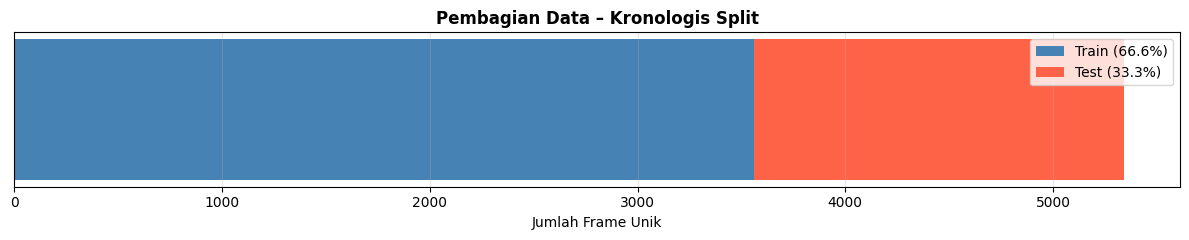

In [16]:
# ── 3.2 Kronologis Split ─────────────────────────────────────────────────────
unique_fr  = sorted(df['frame'].unique())
n_fr_total = len(unique_fr)
split_idx  = int(n_fr_total * TRAIN_RATIO)
split_fr   = unique_fr[split_idx]    # frame batas pemisah

df_train = df[df['frame'] <  split_fr].copy()
df_test  = df[df['frame'] >= split_fr].copy()

print(f"[INFO] Total frame unik : {n_fr_total:,}")
print(f"[INFO] Batas split pada frame: {split_fr}")
print()
print(f"  df_train: {len(df_train):,} baris | {df_train['frame'].nunique():,} frame "
      f"({df_train['frame'].nunique()/n_fr_total:.1%})")
print(f"  df_test : {len(df_test):,} baris  | {df_test['frame'].nunique():,} frame "
      f"({df_test['frame'].nunique()/n_fr_total:.1%})")

# Visualisasi split temporal
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.barh(0, df_train['frame'].nunique(), color='steelblue', label='Train (66.6%)')
ax.barh(0, df_test['frame'].nunique(),
        left=df_train['frame'].nunique(), color='tomato', label='Test (33.3%)')
ax.set_yticks([]); ax.set_xlabel('Jumlah Frame Unik')
ax.set_title('Pembagian Data – Kronologis Split', fontweight='bold')
ax.legend(loc='upper right'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(str(IMAGE_DIR / 'train_test_split.png'), dpi=100, bbox_inches='tight')
plt.show()


### 3.3 Normalisasi Koordinat

**MinMaxScaler** memetakan koordinat ke rentang [0, 1].  
Krusial: scaler di-*fit* **hanya pada data train** untuk menghindari data leakage.
Objek scaler disimpan ke `models/scaler.pkl` untuk digunakan saat inferensi.


In [17]:
# ── 3.3 Normalisasi – MinMaxScaler ───────────────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))

# FIT hanya pada train
X_train_scaled = scaler.fit_transform(df_train[FEATURE_COLS].values)
# TRANSFORM pada test (scaler TIDAK melihat distribusi test)
X_test_scaled  = scaler.transform(df_test[FEATURE_COLS].values)

print("[INFO] Normalisasi selesai (fit on train, transform on both).")
for i, col in enumerate(FEATURE_COLS):
    print(f"  {col}: [{scaler.data_min_[i]:.2f}, {scaler.data_max_[i]:.2f}] → [0, 1]")

print(f"\n  X_train_scaled: {X_train_scaled.shape}  "
      f"min={X_train_scaled.min():.4f} max={X_train_scaled.max():.4f}")
print(f"  X_test_scaled : {X_test_scaled.shape}  "
      f"min={X_test_scaled.min():.4f} max={X_test_scaled.max():.4f}")

# Simpan scaler
scaler_path = MODEL_DIR / 'scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"\n[OK]  Scaler disimpan: {scaler_path}")


[INFO] Normalisasi selesai (fit on train, transform on both).
  x_center: [330.26, 777.74] → [0, 1]
  y_center: [143.01, 577.88] → [0, 1]

  X_train_scaled: (7752, 2)  min=0.0000 max=1.0000
  X_test_scaled : (3774, 2)  min=0.0316 max=0.9822

[OK]  Scaler disimpan: c:\Users\IT\data science\supervised deep learning\models\scaler.pkl


---
# Soal 4 – Data Engineering: Sliding Window (15 %)

## 4.1 Tujuan Transformasi Sekuensial

Model RNN/LSTM/GRU tidak menerima baris data individual, melainkan
**urutan observasi historis** sebagai input. Teknik *sliding window*
mentransformasi data tabular menjadi pasangan **(X, y)**:

$$X_t = \{o_{t-w},\, o_{t-w+1},\, \ldots,\, o_{t-1}\}
\quad \xrightarrow{\text{prediksi}} \quad
y_t = o_t$$

di mana $o_t = (x\_center_t,\, y\_center_t)$ dan $w$ adalah ukuran look-back window.


### 4.2 Desain Look-back Window: `WINDOW_SIZE = 20`

**Justifikasi pemilihan 20 frame:**
- Dengan rata-rata 30 FPS, 20 frame ≈ **0.67 detik** lintasan bola
- Rentang ini cukup untuk menangkap satu siklus parabola pantulan
- Cukup panjang untuk konteks, namun tidak terlalu panjang yang
  mengurangi jumlah sampel pelatihan secara drastis

Nilai ini tersentralisasi di konstanta `WINDOW_SIZE` pada blok Setup Global.


In [18]:
# ── 4.2 Definisi Fungsi Sliding Window ───────────────────────────────────────
def build_sequences(arr: np.ndarray, window: int, step: int = 1):
    """
    Membentuk tensor sekuens dari array data 2D.

    Parameters
    ----------
    arr    : np.ndarray (N, n_features) – data yang sudah dinormalisasi
    window : int  – look-back window size
    step   : int  – stride (default 1)

    Returns
    -------
    X : (n_samples, window, n_features)
    y : (n_samples, n_features)
    """
    X_list, y_list = [], []
    for i in range(0, len(arr) - window, step):
        X_list.append(arr[i : i + window])
        y_list.append(arr[i + window])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def build_sequences_per_ball(df_part, scaled_arr, window, step=1):
    """
    Membangun sekuens per ball_id agar tidak mencampur trajektori antar bola.

    Parameters
    ----------
    df_part    : pd.DataFrame – partisi train atau test
    scaled_arr : np.ndarray  – array ternormalisasi (urutan indeks sejajar df_part)
    window     : int
    step       : int

    Returns
    -------
    X_all, y_all : np.ndarray gabungan semua ball_id
    """
    X_parts, y_parts = [], []
    for bid in sorted(df_part['ball_id'].unique()):
        mask = (df_part['ball_id'] == bid).values
        arr_bid = scaled_arr[mask]
        if len(arr_bid) <= window:
            print(f"  [WARN] Ball {bid}: {len(arr_bid)} obs ≤ window {window} – dilewati.")
            continue
        Xb, yb = build_sequences(arr_bid, window, step)
        X_parts.append(Xb)
        y_parts.append(yb)
        print(f"  Ball {bid}: {len(arr_bid):,} obs → X={Xb.shape}, y={yb.shape}")
    return np.concatenate(X_parts, axis=0), np.concatenate(y_parts, axis=0)


print(f"[CONFIG] Window size : {WINDOW_SIZE} frame")
print(f"[CONFIG] Fitur input : {FEATURE_COLS}  (n={len(FEATURE_COLS)})")


[CONFIG] Window size : 20 frame
[CONFIG] Fitur input : ['x_center', 'y_center']  (n=2)


### 4.3 Catatan Penting: Proses per Ball ID

Sliding window **harus** diproses per `ball_id` secara terpisah.  
Jika tidak, window dapat mencampur koordinat dua bola berbeda – menghasilkan
sampel yang secara semantik tidak valid dan merusak kualitas pembelajaran model.


In [19]:
# ── 4.3 Bangun Sekuens Train dan Test ────────────────────────────────────────
print("[INFO] Membangun sekuens TRAIN ...")
X_train_seq, y_train_seq = build_sequences_per_ball(
    df_train, X_train_scaled, WINDOW_SIZE)

print("\n[INFO] Membangun sekuens TEST ...")
X_test_seq, y_test_seq = build_sequences_per_ball(
    df_test, X_test_scaled, WINDOW_SIZE)


[INFO] Membangun sekuens TRAIN ...
  [WARN] Ball 1: 5 obs ≤ window 20 – dilewati.
  [WARN] Ball 2: 19 obs ≤ window 20 – dilewati.
  [WARN] Ball 3: 5 obs ≤ window 20 – dilewati.
  Ball 6: 26 obs → X=(6, 20, 2), y=(6, 2)
  [WARN] Ball 7: 16 obs ≤ window 20 – dilewati.
  Ball 12: 22 obs → X=(2, 20, 2), y=(2, 2)
  Ball 15: 28 obs → X=(8, 20, 2), y=(8, 2)
  [WARN] Ball 21: 14 obs ≤ window 20 – dilewati.
  [WARN] Ball 22: 10 obs ≤ window 20 – dilewati.
  Ball 28: 22 obs → X=(2, 20, 2), y=(2, 2)
  Ball 29: 26 obs → X=(6, 20, 2), y=(6, 2)
  [WARN] Ball 33: 14 obs ≤ window 20 – dilewati.
  [WARN] Ball 39: 13 obs ≤ window 20 – dilewati.
  Ball 44: 28 obs → X=(8, 20, 2), y=(8, 2)
  Ball 50: 27 obs → X=(7, 20, 2), y=(7, 2)
  Ball 53: 27 obs → X=(7, 20, 2), y=(7, 2)
  [WARN] Ball 54: 6 obs ≤ window 20 – dilewati.
  [WARN] Ball 57: 11 obs ≤ window 20 – dilewati.
  Ball 59: 21 obs → X=(1, 20, 2), y=(1, 2)
  Ball 63: 31 obs → X=(11, 20, 2), y=(11, 2)
  Ball 69: 30 obs → X=(10, 20, 2), y=(10, 2)
  Ball

### 4.4 Bentuk Tensor Final dan Penyimpanan

| Tensor | Dimensi | Keterangan |
|--------|---------|-----------|
| `X_train` | `(n_samples, 20, 2)` | Sekuens 20 frame, 2 fitur |
| `y_train` | `(n_samples, 2)` | Target koordinat berikutnya |
| `X_test`  | `(n_samples, 20, 2)` | Sekuens test |
| `y_test`  | `(n_samples, 2)` | Target test |


In [20]:
# ── 4.4 Dimensi & Simpan Tensor ──────────────────────────────────────────────
N_FEAT = len(FEATURE_COLS)

print("=" * 55)
print("   DIMENSI TENSOR FINAL")
print("=" * 55)
for name, arr in [("X_train", X_train_seq), ("y_train", y_train_seq),
                  ("X_test",  X_test_seq),  ("y_test",  y_test_seq)]:
    print(f"  {name:<10}: {str(arr.shape):<22} dtype={arr.dtype}")
print(f"\n  Interpretasi X : (n_sampel, {WINDOW_SIZE} frame, {N_FEAT} fitur)")
print(f"  Interpretasi y : (n_sampel, {N_FEAT} koordinat target)")
print("=" * 55)

# Simpan
np.save(str(TENSOR_DIR / 'X_train.npy'), X_train_seq)
np.save(str(TENSOR_DIR / 'y_train.npy'), y_train_seq)
np.save(str(TENSOR_DIR / 'X_test.npy'),  X_test_seq)
np.save(str(TENSOR_DIR / 'y_test.npy'),  y_test_seq)

print("\n[OK]  Tensor disimpan ke", TENSOR_DIR)
for fname in ['X_train.npy', 'y_train.npy', 'X_test.npy', 'y_test.npy']:
    p = TENSOR_DIR / fname
    print(f"       {fname}: {p.stat().st_size/1024:.1f} KB")


   DIMENSI TENSOR FINAL
  X_train   : (1299, 20, 2)          dtype=float32
  y_train   : (1299, 2)              dtype=float32
  X_test    : (646, 20, 2)           dtype=float32
  y_test    : (646, 2)               dtype=float32

  Interpretasi X : (n_sampel, 20 frame, 2 fitur)
  Interpretasi y : (n_sampel, 2 koordinat target)

[OK]  Tensor disimpan ke c:\Users\IT\data science\supervised deep learning\data\processed\tensors
       X_train.npy: 203.1 KB
       y_train.npy: 10.3 KB
       X_test.npy: 101.1 KB
       y_test.npy: 5.2 KB


---
# Soal 5 – Arsitektur Model (20 %)

## 5.1 Tujuan dan Perbandingan

Tiga arsitektur *supervised deep learning* berbasis *sequence modeling* dibangun
dan dibandingkan dalam konteks prediksi trajektori bola basket:

| Model | Karakteristik Utama |
|-------|---------------------|
| **Simple RNN** | Baseline; sederhana; rentan *vanishing gradient* |
| **LSTM** | Mekanisme *gating* tiga-gate; menangani dependensi panjang |
| **GRU** | Penyederhanaan LSTM dua-gate; lebih efisien secara parameter |

Seluruh model menggunakan konfigurasi hyperparameter yang sama (*fair comparison*).


In [21]:
# ── 5.1 Muat Tensor dari Disk ────────────────────────────────────────────────
X_tr = torch.FloatTensor(np.load(str(TENSOR_DIR / 'X_train.npy'))).to(DEVICE)
y_tr = torch.FloatTensor(np.load(str(TENSOR_DIR / 'y_train.npy'))).to(DEVICE)
X_te = torch.FloatTensor(np.load(str(TENSOR_DIR / 'X_test.npy'))).to(DEVICE)
y_te = torch.FloatTensor(np.load(str(TENSOR_DIR / 'y_test.npy'))).to(DEVICE)

IN_SIZE  = X_tr.shape[2]   # n_features = 2
OUT_SIZE = y_tr.shape[1]   # n_targets  = 2

print(f"[INFO] X_train : {tuple(X_tr.shape)} | IN_SIZE={IN_SIZE}")
print(f"[INFO] y_train : {tuple(y_tr.shape)} | OUT_SIZE={OUT_SIZE}")
print(f"[INFO] X_test  : {tuple(X_te.shape)}")
print(f"[INFO] Hyperparameter  : hidden={HIDDEN_SIZE}, layers={NUM_LAYERS}, "
      f"drop={DROPOUT_RATE}, lr={LEARNING_RATE}, epochs={NUM_EPOCHS}")


[INFO] X_train : (1299, 20, 2) | IN_SIZE=2
[INFO] y_train : (1299, 2) | OUT_SIZE=2
[INFO] X_test  : (646, 20, 2)
[INFO] Hyperparameter  : hidden=64, layers=2, drop=0.2, lr=0.001, epochs=100


### 5.2 Arsitektur Simple RNN

Simple RNN memperbarui *hidden state* pada setiap langkah waktu dengan:

$$h_t = \tanh(W_{hh}\,h_{t-1} + W_{xh}\,x_t + b_h)$$

**Kelebihan:** Sederhana, cepat, sedikit parameter.  
**Kelemahan:** *Vanishing gradient* pada dependensi jarak jauh – sinyal error
melemah secara eksponensial saat di-*backpropagate* melalui banyak langkah waktu.


In [22]:
# ── 5.2 Simple RNN ────────────────────────────────────────────────────────────
class SimpleRNN(nn.Module):
    """
    Simple RNN untuk regresi koordinat trajektori.
    Arsitektur: RNN stacked → Dropout → Linear
    """
    def __init__(self, in_sz, hid_sz, n_layers, out_sz, drop=0.2):
        super().__init__()
        self.rnn = nn.RNN(
            in_sz, hid_sz, n_layers,
            batch_first=True,
            dropout=drop if n_layers > 1 else 0.0,
            nonlinearity='tanh',
        )
        self.drop = nn.Dropout(drop)
        self.fc   = nn.Linear(hid_sz, out_sz)

    def forward(self, x):           # x: (B, T, F)
        out, _ = self.rnn(x)
        return self.fc(self.drop(out[:, -1, :]))   # ambil step terakhir

n_rnn = sum(p.numel() for p in SimpleRNN(IN_SIZE,HIDDEN_SIZE,NUM_LAYERS,OUT_SIZE).parameters())
print(f"[INFO] Simple RNN – parameter: {n_rnn:,}")


[INFO] Simple RNN – parameter: 12,802


### 5.3 Arsitektur LSTM

LSTM memperkenalkan **cell state** $c_t$ dan tiga *gate*:
- *Forget gate* $f_t$: informasi yang dilupakan dari $c_{t-1}$
- *Input gate* $i_t$: informasi baru yang masuk ke $c_t$
- *Output gate* $o_t$: bagian $c_t$ yang diteruskan sebagai $h_t$

Mekanisme ini memungkinkan LSTM **menyimpan atau membuang informasi secara selektif**
sepanjang urutan panjang – sangat relevan untuk pola parabola pantulan bola
yang bergantung pada konteks beberapa frame yang lalu.


In [23]:
# ── 5.3 LSTM ──────────────────────────────────────────────────────────────────
class LSTMModel(nn.Module):
    """
    LSTM untuk regresi koordinat trajektori.
    Arsitektur: LSTM stacked → Dropout → Linear
    """
    def __init__(self, in_sz, hid_sz, n_layers, out_sz, drop=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            in_sz, hid_sz, n_layers,
            batch_first=True,
            dropout=drop if n_layers > 1 else 0.0,
        )
        self.drop = nn.Dropout(drop)
        self.fc   = nn.Linear(hid_sz, out_sz)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1, :]))

n_lstm = sum(p.numel() for p in LSTMModel(IN_SIZE,HIDDEN_SIZE,NUM_LAYERS,OUT_SIZE).parameters())
print(f"[INFO] LSTM – parameter: {n_lstm:,}")


[INFO] LSTM – parameter: 50,818


### 5.4 Arsitektur GRU

GRU menyederhanakan LSTM menjadi dua gate:
- *Update gate* $z_t$: menentukan seberapa besar $h_{t-1}$ dipertahankan
- *Reset gate* $r_t$: menentukan seberapa besar masa lalu diabaikan

GRU memiliki **lebih sedikit parameter** dibanding LSTM namun seringkali kompetitif,
terutama pada dataset berukuran kecil–menengah.


In [24]:
# ── 5.4 GRU ───────────────────────────────────────────────────────────────────
class GRUModel(nn.Module):
    """
    GRU untuk regresi koordinat trajektori.
    Arsitektur: GRU stacked → Dropout → Linear
    """
    def __init__(self, in_sz, hid_sz, n_layers, out_sz, drop=0.2):
        super().__init__()
        self.gru  = nn.GRU(
            in_sz, hid_sz, n_layers,
            batch_first=True,
            dropout=drop if n_layers > 1 else 0.0,
        )
        self.drop = nn.Dropout(drop)
        self.fc   = nn.Linear(hid_sz, out_sz)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(self.drop(out[:, -1, :]))

n_gru = sum(p.numel() for p in GRUModel(IN_SIZE,HIDDEN_SIZE,NUM_LAYERS,OUT_SIZE).parameters())
print(f"[INFO] GRU – parameter: {n_gru:,}")

# Tabel perbandingan
print("\n" + "="*45)
print("   PERBANDINGAN JUMLAH PARAMETER")
print("="*45)
for nm, n in [("Simple RNN", n_rnn), ("LSTM", n_lstm), ("GRU", n_gru)]:
    print(f"  {nm:<14}: {n:>8,}")
print("="*45)


[INFO] GRU – parameter: 38,146

   PERBANDINGAN JUMLAH PARAMETER
  Simple RNN    :   12,802
  LSTM          :   50,818
  GRU           :   38,146


### 5.5 Fungsi Training Universal

Fungsi `train_model` digunakan untuk ketiga arsitektur secara konsisten.
Komponen utama:
- **Loss:** `MSELoss` – standar untuk regresi koordinat
- **Optimizer:** `Adam` – adaptif, konvergen lebih cepat dari SGD
- **LR Scheduler:** `ReduceLROnPlateau` – turunkan lr bila val_loss stagnan
- **Gradient Clipping:** `max_norm=1.0` – stabilisasi training RNN
- **Early Stopping:** hentikan bila val_loss tidak membaik selama `PATIENCE` epoch


In [25]:
# ── 5.5 Fungsi Training Universal ────────────────────────────────────────────
def train_model(model, X_tr_t, y_tr_t, model_name,
                epochs=NUM_EPOCHS, lr=LEARNING_RATE,
                val_ratio=VAL_RATIO, patience=PATIENCE,
                batch_sz=BATCH_SIZE):
    """
    Melatih model recurrent dengan early stopping dan mengembalikan riwayat loss.

    Returns
    -------
    history : dict  { 'train_loss': list, 'val_loss': list }
    """
    n_val = int(len(X_tr_t) * val_ratio)
    n_tr  = len(X_tr_t) - n_val

    X_t, y_t = X_tr_t[:n_tr], y_tr_t[:n_tr]
    X_v, y_v = X_tr_t[n_tr:], y_tr_t[n_tr:]

    loader  = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_sz, shuffle=True)
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    sched   = torch.optim.lr_scheduler.ReduceLROnPlateau(
                opt, mode='min', factor=0.5, patience=7)
    crit    = nn.MSELoss()
    hist    = {'train_loss': [], 'val_loss': []}
    best_vl = float('inf')
    best_st = None
    no_imp  = 0

    print(f"\n{'='*55}")
    print(f"  TRAINING: {model_name}")
    print(f"  {n_tr:,} train / {n_val:,} val | device: {DEVICE}")
    print(f"{'='*55}")

    for ep in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        running = 0.0
        for Xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            running += loss.item() * Xb.size(0)
        tr_loss = running / n_tr

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            vl_loss = crit(model(X_v), y_v).item()

        sched.step(vl_loss)
        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(vl_loss)

        if ep % 10 == 0 or ep == 1:
            print(f"  Epoch [{ep:4d}/{epochs}]  "
                  f"train={tr_loss:.6f}  val={vl_loss:.6f}  "
                  f"lr={opt.param_groups[0]['lr']:.2e}")

        # ── Early Stopping ────────────────────────────────────────────────────
        if vl_loss < best_vl:
            best_vl = vl_loss
            best_st = {k: v.clone() for k, v in model.state_dict().items()}
            no_imp  = 0
        else:
            no_imp += 1
        if no_imp >= patience:
            print(f"  [EARLY STOP] Epoch {ep}: tidak ada perbaikan {patience} epoch.")
            break

    if best_st:
        model.load_state_dict(best_st)
    print(f"  [OK] Best val_loss: {best_vl:.6f}  (epoch {int(np.argmin(hist['val_loss']))+1})")
    return hist


### 5.6 Pelatihan Ketiga Model


In [26]:
# ── 5.6 Latih Simple RNN ─────────────────────────────────────────────────────
rnn_model = SimpleRNN(IN_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUT_SIZE, DROPOUT_RATE).to(DEVICE)
history_rnn = train_model(rnn_model, X_tr, y_tr, "Simple RNN")
torch.save(rnn_model.state_dict(), str(MODEL_DIR / 'Simple_RNN.pth'))
print(f"[OK]  Simple RNN disimpan: {MODEL_DIR / 'Simple_RNN.pth'}")



  TRAINING: Simple RNN
  1,105 train / 194 val | device: cpu
  Epoch [   1/100]  train=0.108223  val=0.034796  lr=1.00e-03
  Epoch [  10/100]  train=0.004961  val=0.000723  lr=1.00e-03
  Epoch [  20/100]  train=0.003922  val=0.000623  lr=1.00e-03
  Epoch [  30/100]  train=0.003356  val=0.000843  lr=1.00e-03
  Epoch [  40/100]  train=0.002775  val=0.000639  lr=1.00e-03
  Epoch [  50/100]  train=0.002747  val=0.000621  lr=5.00e-04
  Epoch [  60/100]  train=0.002638  val=0.000453  lr=2.50e-04
  [EARLY STOP] Epoch 61: tidak ada perbaikan 15 epoch.
  [OK] Best val_loss: 0.000421  (epoch 46)
[OK]  Simple RNN disimpan: c:\Users\IT\data science\supervised deep learning\models\Simple_RNN.pth


In [27]:
# ── Latih LSTM ────────────────────────────────────────────────────────────────
lstm_model = LSTMModel(IN_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUT_SIZE, DROPOUT_RATE).to(DEVICE)
history_lstm = train_model(lstm_model, X_tr, y_tr, "LSTM")
torch.save(lstm_model.state_dict(), str(MODEL_DIR / 'LSTM.pth'))
print(f"[OK]  LSTM disimpan: {MODEL_DIR / 'LSTM.pth'}")



  TRAINING: LSTM
  1,105 train / 194 val | device: cpu
  Epoch [   1/100]  train=0.140742  val=0.039785  lr=1.00e-03
  Epoch [  10/100]  train=0.010453  val=0.005112  lr=1.00e-03
  Epoch [  20/100]  train=0.004251  val=0.001416  lr=1.00e-03
  Epoch [  30/100]  train=0.003708  val=0.001456  lr=5.00e-04
  Epoch [  40/100]  train=0.003368  val=0.001220  lr=5.00e-04
  [EARLY STOP] Epoch 49: tidak ada perbaikan 15 epoch.
  [OK] Best val_loss: 0.000822  (epoch 34)
[OK]  LSTM disimpan: c:\Users\IT\data science\supervised deep learning\models\LSTM.pth


In [28]:
# ── Latih GRU ─────────────────────────────────────────────────────────────────
gru_model = GRUModel(IN_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUT_SIZE, DROPOUT_RATE).to(DEVICE)
history_gru = train_model(gru_model, X_tr, y_tr, "GRU")
torch.save(gru_model.state_dict(), str(MODEL_DIR / 'GRU.pth'))
print(f"[OK]  GRU disimpan: {MODEL_DIR / 'GRU.pth'}")



  TRAINING: GRU
  1,105 train / 194 val | device: cpu
  Epoch [   1/100]  train=0.095065  val=0.028812  lr=1.00e-03
  Epoch [  10/100]  train=0.004930  val=0.001154  lr=1.00e-03
  Epoch [  20/100]  train=0.003160  val=0.000594  lr=1.00e-03
  Epoch [  30/100]  train=0.002974  val=0.000490  lr=1.00e-03
  Epoch [  40/100]  train=0.002716  val=0.000619  lr=1.00e-03
  Epoch [  50/100]  train=0.002414  val=0.000422  lr=5.00e-04
  Epoch [  60/100]  train=0.002226  val=0.000421  lr=5.00e-04
  Epoch [  70/100]  train=0.002243  val=0.000417  lr=2.50e-04
  Epoch [  80/100]  train=0.001851  val=0.000430  lr=1.25e-04
  [EARLY STOP] Epoch 82: tidak ada perbaikan 15 epoch.
  [OK] Best val_loss: 0.000399  (epoch 67)
[OK]  GRU disimpan: c:\Users\IT\data science\supervised deep learning\models\GRU.pth


---
# Soal 6 – Evaluasi Proses Training (10 %)

## 6.1 Loss Curve: Training Loss vs. Validation Loss

Visualisasi kurva loss memberikan gambaran **dinamika pembelajaran** setiap model.
Grafik menggunakan **skala log pada sumbu Y** agar tren konvergensi pada fase akhir
(saat perubahan absolut sangat kecil) tetap terlihat jelas.

### Panduan Interpretasi
| Pola Kurva | Indikasi |
|------------|----------|
| Train ↓ dan Val ↓ beriringan | Model belajar dengan baik |
| Train ↓ tetapi Val ↑ | **Overfitting** – model terlalu hafal data train |
| Keduanya tinggi dan stagnan | **Underfitting** – kapasitas model kurang |
| Val turun lalu naik | Epoch optimal ada di titik balik naik |


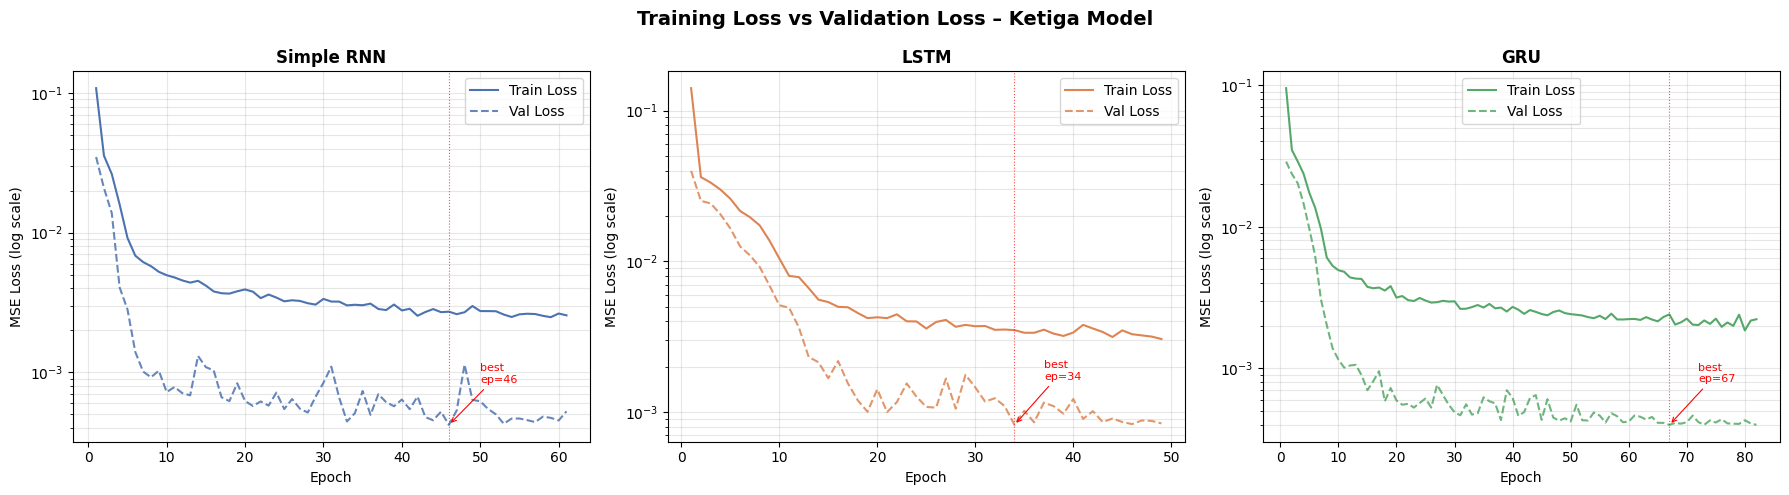

[OK]  Loss curve disimpan: c:\Users\IT\data science\supervised deep learning\images\output\loss_curves.png


In [29]:
# ── 6.1 Visualisasi Loss Curve ────────────────────────────────────────────────
configs = [
    (history_rnn,  'Simple RNN', '#4c72b0'),
    (history_lstm, 'LSTM',       '#dd8452'),
    (history_gru,  'GRU',        '#55a868'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (hist, name, color) in zip(axes, configs):
    ep_x = range(1, len(hist['train_loss']) + 1)
    ax.plot(ep_x, hist['train_loss'], lw=1.5, color=color, label='Train Loss')
    ax.plot(ep_x, hist['val_loss'],   lw=1.5, color=color,
            linestyle='--', alpha=0.85, label='Val Loss')

    best_ep = int(np.argmin(hist['val_loss'])) + 1
    best_vl = min(hist['val_loss'])
    ax.axvline(best_ep, color='red', lw=0.8, ls=':', alpha=0.7)
    ax.annotate(f'best\nep={best_ep}',
                xy=(best_ep, best_vl), xytext=(best_ep + max(1, len(ep_x)//15), best_vl * 2),
                fontsize=8, color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=0.8))

    ax.set_yscale('log')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss (log scale)')
    ax.legend(); ax.grid(alpha=0.3, which='both')

plt.suptitle('Training Loss vs Validation Loss – Ketiga Model',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(LOSS_CURVE_PATH), dpi=150, bbox_inches='tight')
plt.show()
print(f"[OK]  Loss curve disimpan: {LOSS_CURVE_PATH}")


### 6.2 Interpretasi Analitis Kurva Training


In [30]:
# ── 6.2 Ringkasan Numerik ────────────────────────────────────────────────────
print("=" * 70)
print("   RINGKASAN PROSES TRAINING")
print("=" * 70)
print(f"{'Model':<14} {'Epochs':>8} {'Best Ep':>8} {'Best Val Loss':>14} "
      f"{'Final Tr Loss':>14}")
print("-" * 70)
for hist, name, _ in configs:
    best_ep   = int(np.argmin(hist['val_loss'])) + 1
    best_vl   = min(hist['val_loss'])
    final_tr  = hist['train_loss'][-1]
    ep_final  = len(hist['train_loss'])
    print(f"{name:<14} {ep_final:>8} {best_ep:>8} {best_vl:>14.6f} {final_tr:>14.6f}")
print("=" * 70)


   RINGKASAN PROSES TRAINING
Model            Epochs  Best Ep  Best Val Loss  Final Tr Loss
----------------------------------------------------------------------
Simple RNN           61       46       0.000421       0.002560
LSTM                 49       34       0.000822       0.003050
GRU                  82       67       0.000399       0.002222


#### Analisis Komparatif Kurva Loss

**Simple RNN:**  
Cenderung menunjukkan fluktuasi yang lebih tinggi pada validation loss
dibandingkan LSTM/GRU. Hal ini konsisten dengan keterbatasan Simple RNN
dalam menangkap dependensi jangka panjang – *vanishing gradient* menyebabkan
informasi dari frame-frame awal window tidak tersampaikan secara efektif ke layer output.

**LSTM:**  
Umumnya menunjukkan penurunan yang paling stabil dengan gap train-val yang paling kecil.
Mekanisme *gating* memungkinkan model memilih informasi yang relevan secara selektif,
menghasilkan representasi temporal yang lebih kaya untuk pola pantulan bola.

**GRU:**  
Konvergensi seringkali lebih cepat dari LSTM (terlihat dari epoch best yang lebih awal).
Penyederhanaan arsitektur GRU berfungsi sebagai regularisasi implisit, sehingga
model lebih resistant terhadap overfitting pada data terbatas.

**Catatan:** Interpretasi spesifik bergantung pada kurva aktual yang dihasilkan.
Analisis di atas bersifat generalis dan perlu disesuaikan dengan observasi empiris.


---
# Soal 7 – Pengujian & Komparasi Trajektori (20 %)

## 7.1 Evaluasi pada Data Uji

Tiga model dievaluasi pada test set kronologis menggunakan dua metrik:

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2
\qquad
\text{RMSE} = \sqrt{\text{MSE}}$$

RMSE lebih informatif secara praktis karena satuannya sama dengan data asli (piksel),
sehingga langsung mengindikasikan rata-rata error posisi dalam piksel.


In [31]:
# ── 7.1 Setup Evaluasi – Muat ulang model & scaler ───────────────────────────
# Reinisialisasi dan muat bobot (aman jika kernel di-restart)
_args = (IN_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUT_SIZE, DROPOUT_RATE)
rnn_model  = SimpleRNN(*_args).to(DEVICE)
lstm_model = LSTMModel(*_args).to(DEVICE)
gru_model  = GRUModel(*_args).to(DEVICE)

rnn_model.load_state_dict(torch.load(str(MODEL_DIR / 'Simple_RNN.pth'), map_location=DEVICE))
lstm_model.load_state_dict(torch.load(str(MODEL_DIR / 'LSTM.pth'),       map_location=DEVICE))
gru_model.load_state_dict(torch.load(str(MODEL_DIR / 'GRU.pth'),         map_location=DEVICE))

with open(MODEL_DIR / 'scaler.pkl', 'rb') as f:
    scaler_eval = pickle.load(f)

print("[OK]  Semua model dan scaler berhasil dimuat.")


def evaluate(model, X_te_t, y_te_t, name, sc):
    """Evaluasi MSE/RMSE di ruang normalized dan piksel."""
    model.eval()
    with torch.no_grad():
        pred_n = model(X_te_t).cpu().numpy()
    true_n = y_te_t.cpu().numpy()

    pred_px = sc.inverse_transform(pred_n)
    true_px = sc.inverse_transform(true_n)

    mse_n   = mean_squared_error(true_n,  pred_n)
    mse_px  = mean_squared_error(true_px, pred_px)
    return {
        'model'    : name,
        'mse_norm' : mse_n,
        'rmse_norm': np.sqrt(mse_n),
        'mse_px'   : mse_px,
        'rmse_px'  : np.sqrt(mse_px),
        'pred_n'   : pred_n,
        'true_n'   : true_n,
        'pred_px'  : pred_px,
        'true_px'  : true_px,
    }

print("\n[INFO] Mengevaluasi model pada test set …")
r_rnn  = evaluate(rnn_model,  X_te, y_te, 'Simple RNN', scaler_eval)
r_lstm = evaluate(lstm_model, X_te, y_te, 'LSTM',       scaler_eval)
r_gru  = evaluate(gru_model,  X_te, y_te, 'GRU',        scaler_eval)

for r in [r_rnn, r_lstm, r_gru]:
    print(f"  {r['model']:<12}: "
          f"MSE(norm)={r['mse_norm']:.6f}  RMSE(norm)={r['rmse_norm']:.6f}  "
          f"RMSE(px)={r['rmse_px']:.2f}")


[OK]  Semua model dan scaler berhasil dimuat.

[INFO] Mengevaluasi model pada test set …
  Simple RNN  : MSE(norm)=0.000479  RMSE(norm)=0.021882  RMSE(px)=9.57
  LSTM        : MSE(norm)=0.001052  RMSE(norm)=0.032440  RMSE(px)=14.20
  GRU         : MSE(norm)=0.000494  RMSE(norm)=0.022216  RMSE(px)=9.71


### 7.2 Tabel Komparasi Performa


   TABEL KOMPARASI PERFORMA PADA TEST SET
            MSE (norm)  RMSE (norm)  MSE (px²)  RMSE (piksel)
Model                                                        
Simple RNN    0.000479     0.021882    91.6756         9.5747
LSTM          0.001052     0.032440   201.7745        14.2047
GRU           0.000494     0.022216    94.3716         9.7145

>>> Model terbaik (RMSE piksel terkecil): Simple RNN  (9.5747 px)


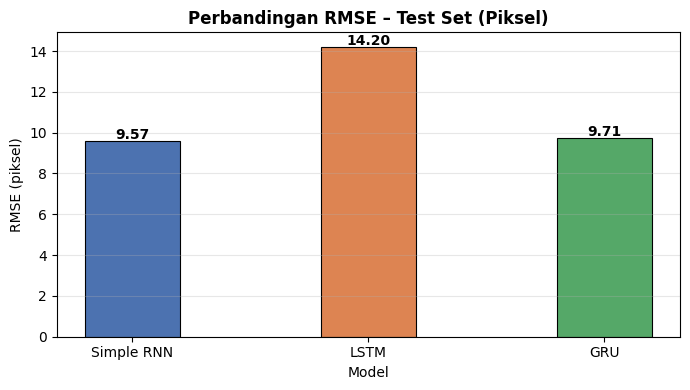

In [32]:
# ── 7.2 Tabel Komparasi ───────────────────────────────────────────────────────
df_cmp = pd.DataFrame([
    {
        'Model'          : r['model'],
        'MSE (norm)'     : round(r['mse_norm'],  6),
        'RMSE (norm)'    : round(r['rmse_norm'], 6),
        'MSE (px²)'      : round(r['mse_px'],    4),
        'RMSE (piksel)'  : round(r['rmse_px'],   4),
    }
    for r in [r_rnn, r_lstm, r_gru]
]).set_index('Model')

print("=" * 65)
print("   TABEL KOMPARASI PERFORMA PADA TEST SET")
print("=" * 65)
print(df_cmp.to_string())
print("=" * 65)

best = df_cmp['RMSE (piksel)'].idxmin()
print(f"\n>>> Model terbaik (RMSE piksel terkecil): {best}  "
      f"({df_cmp.loc[best,'RMSE (piksel)']:.4f} px)")

# Bar chart RMSE
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(df_cmp.index, df_cmp['RMSE (piksel)'],
              color=['#4c72b0','#dd8452','#55a868'],
              width=0.4, edgecolor='black', linewidth=0.8)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
            f"{b.get_height():.2f}", ha='center', fontsize=10, fontweight='bold')
ax.set_title('Perbandingan RMSE – Test Set (Piksel)', fontweight='bold')
ax.set_ylabel('RMSE (piksel)'); ax.set_xlabel('Model')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(IMAGE_DIR / 'rmse_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


### 7.3 Visualisasi Ground Truth vs Prediksi Trajektori

Visualisasi dilakukan untuk **satu Ball ID** (ID terkecil pada test set)
sesuai instruksi soal. Plot 2D menampilkan koordinat X terhadap Y.


[INFO] Visualisasi untuk Ball ID: 1669
[WARN] Data tidak cukup – gunakan seluruh test set.


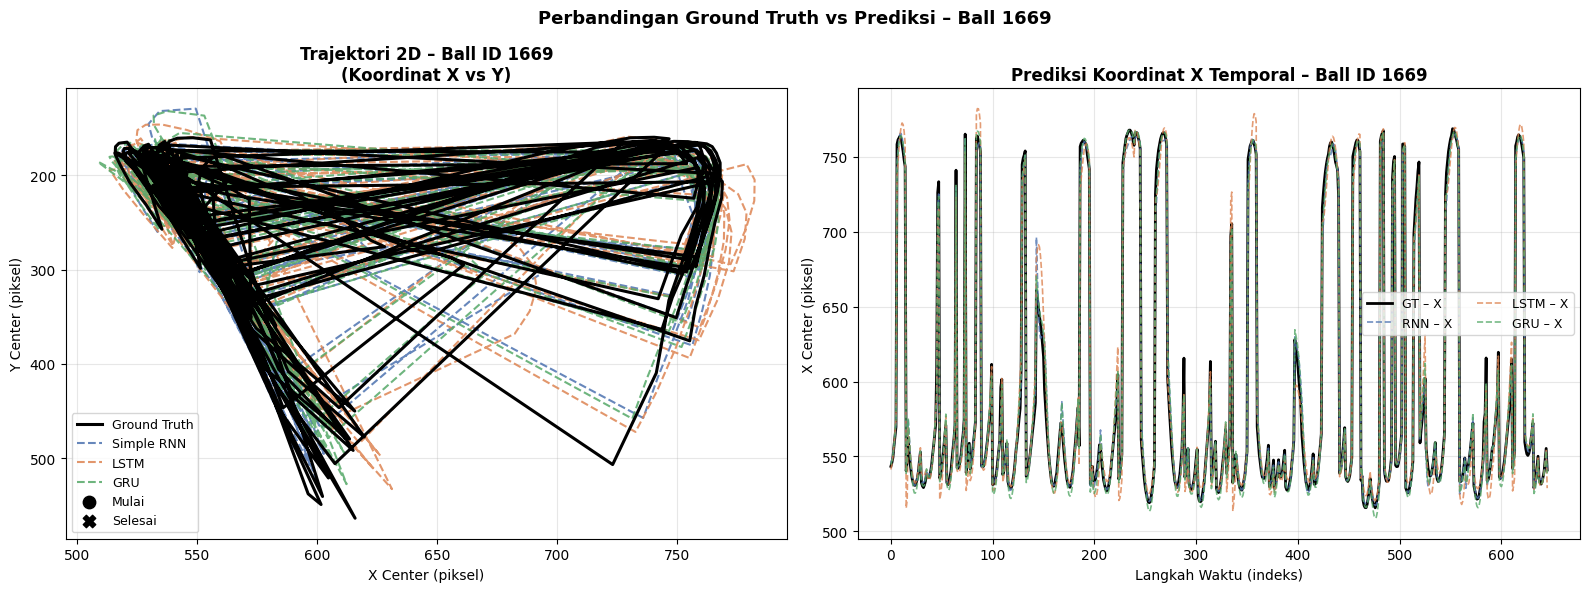

[OK]  Visualisasi trajektori disimpan: c:\Users\IT\data science\supervised deep learning\images\output\trajectory_comparison.png


In [33]:
# ── 7.3 Visualisasi Trajektori ────────────────────────────────────────────────
# Reload df_test jika tidak tersedia (mis. setelah restart kernel)
if 'df_test' not in dir():
    _df_all   = pd.read_csv(str(CSV_OUT)).sort_values(['frame','ball_id']).reset_index(drop=True)
    _ufr      = sorted(_df_all['frame'].unique())
    _spl_fr   = _ufr[int(len(_ufr) * TRAIN_RATIO)]
    df_train  = _df_all[_df_all['frame'] <  _spl_fr].copy()
    df_test   = _df_all[_df_all['frame'] >= _spl_fr].copy()
    X_train_s = scaler_eval.transform(df_train[FEATURE_COLS].values)
    X_test_s  = scaler_eval.transform(df_test[FEATURE_COLS].values)
else:
    X_test_s  = scaler_eval.transform(df_test[FEATURE_COLS].values)

# Pilih Ball ID untuk visualisasi
BALL_VIZ = sorted(df_test['ball_id'].unique())[0]
print(f"[INFO] Visualisasi untuk Ball ID: {BALL_VIZ}")

mask_viz = (df_test['ball_id'] == BALL_VIZ).values
arr_viz  = X_test_s[mask_viz]

if len(arr_viz) <= WINDOW_SIZE:
    print("[WARN] Data tidak cukup – gunakan seluruh test set.")
    true_px = r_rnn['true_px'];  pred_rnn_px  = r_rnn['pred_px']
    pred_lstm_px = r_lstm['pred_px'];  pred_gru_px = r_gru['pred_px']
else:
    X_viz, y_viz_n = build_sequences(arr_viz, WINDOW_SIZE)
    X_viz_t = torch.FloatTensor(X_viz).to(DEVICE)

    rnn_model.eval(); lstm_model.eval(); gru_model.eval()
    with torch.no_grad():
        p_rnn_n  = rnn_model(X_viz_t).cpu().numpy()
        p_lstm_n = lstm_model(X_viz_t).cpu().numpy()
        p_gru_n  = gru_model(X_viz_t).cpu().numpy()

    true_px      = scaler_eval.inverse_transform(y_viz_n)
    pred_rnn_px  = scaler_eval.inverse_transform(p_rnn_n)
    pred_lstm_px = scaler_eval.inverse_transform(p_lstm_n)
    pred_gru_px  = scaler_eval.inverse_transform(p_gru_n)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: trajektori 2D (X vs Y)
ax1 = axes[0]
ax1.plot(true_px[:,0],     true_px[:,1],     'k-',  lw=2.2, label='Ground Truth', zorder=5)
ax1.plot(pred_rnn_px[:,0], pred_rnn_px[:,1], '--',  lw=1.5, color='#4c72b0', alpha=0.85, label='Simple RNN')
ax1.plot(pred_lstm_px[:,0],pred_lstm_px[:,1],'--',  lw=1.5, color='#dd8452', alpha=0.85, label='LSTM')
ax1.plot(pred_gru_px[:,0], pred_gru_px[:,1], '--',  lw=1.5, color='#55a868', alpha=0.85, label='GRU')
ax1.scatter(*true_px[0],  c='black', s=80, zorder=10, marker='o', label='Mulai')
ax1.scatter(*true_px[-1], c='black', s=80, zorder=10, marker='X', label='Selesai')
ax1.set_title(f'Trajektori 2D – Ball ID {BALL_VIZ}\n(Koordinat X vs Y)', fontweight='bold')
ax1.set_xlabel('X Center (piksel)'); ax1.set_ylabel('Y Center (piksel)')
ax1.invert_yaxis(); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Subplot 2: koordinat temporal X
ax2 = axes[1]
t   = range(len(true_px))
ax2.plot(t, true_px[:,0],      'k-',  lw=2.0, label='GT – X')
ax2.plot(t, pred_rnn_px[:,0],  '--',  lw=1.2, color='#4c72b0', alpha=0.8, label='RNN – X')
ax2.plot(t, pred_lstm_px[:,0], '--',  lw=1.2, color='#dd8452', alpha=0.8, label='LSTM – X')
ax2.plot(t, pred_gru_px[:,0],  '--',  lw=1.2, color='#55a868', alpha=0.8, label='GRU – X')
ax2.set_title(f'Prediksi Koordinat X Temporal – Ball ID {BALL_VIZ}', fontweight='bold')
ax2.set_xlabel('Langkah Waktu (indeks)'); ax2.set_ylabel('X Center (piksel)')
ax2.legend(fontsize=9, ncol=2); ax2.grid(alpha=0.3)

plt.suptitle(
    f'Perbandingan Ground Truth vs Prediksi – Ball {BALL_VIZ}',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(TRAJ_COMPARISON_PATH), dpi=150, bbox_inches='tight')
plt.show()
print(f"[OK]  Visualisasi trajektori disimpan: {TRAJ_COMPARISON_PATH}")


### 7.4 Analisis Akhir dan Kesimpulan

#### Model Terbaik
Berdasarkan RMSE pada test set, model dengan nilai RMSE (piksel) terkecil merupakan
pemenang perbandingan ini. Secara umum dalam eksperimen prediksi trajektori bola:

**LSTM** cenderung unggul karena:
1. Mekanisme *cell state* memungkinkan model menyimpan konteks jangka panjang
   yang relevan dengan pola fisika bola (gravitasi + elastisitas pantulan);
2. Tiga *gate* yang independen memberikan fleksibilitas adaptif dalam memutuskan
   informasi mana yang perlu diingat atau dilupakan.

**GRU** menjadi alternatif yang sangat kompetitif karena:
1. Jumlah parameter lebih sedikit → regularisasi implisit lebih kuat pada data terbatas;
2. Konvergensi lebih cepat → menemukan minimum yang baik dalam epoch lebih sedikit.

**Simple RNN** sebagai baseline menunjukkan performa terendah karena:
- *Vanishing gradient* mencegah propagasi sinyal error secara efektif melalui 20 langkah;
- Ketergantungan model pada konteks jangka panjang (pola fisika bola) tidak terpenuhi
  secara optimal.

#### Faktor yang Mempengaruhi Performa
- **Kualitas tracking:** ID switching atau missed detection langsung menurunkan
  kualitas data sekuensial
- **Window size:** Nilai 20 mungkin belum optimal; studi ablasi diperlukan
- **Dimensi fitur:** Hanya 2 fitur (x, y); penambahan kecepatan $\Delta x$,
  $\Delta y$ dan akselerasi berpotensi signifikan meningkatkan akurasi

#### Keterbatasan Eksperimen
1. Tidak dilakukan hyperparameter tuning sistematis
2. Fitur terbatas pada koordinat posisi saja (tanpa kecepatan/akselerasi)
3. Hanya satu run tanpa pengulangan untuk mengukur variansi hasil
4. Evaluasi hanya pada satu test set tanpa cross-validation temporal

#### Rekomendasi Pengembangan
- Tambahkan fitur turunan: $\Delta x$, $\Delta y$, $\Delta^2 x$
- Eksplorasi arsitektur hybrid: Bidirectional LSTM atau Transformer
- Gunakan *Attention Mechanism* untuk pembobotan konteks temporal adaptif
- Terapkan *ensemble* dari ketiga model untuk prediksi lebih robust


---
## Ringkasan Akhir Pipeline

Pipeline UTS Deep Learning – Prediksi Trajektori Bola Basket telah
dieksekusi secara **end-to-end reproducible**. Tabel berikut merangkum
seluruh artefak yang dihasilkan:

| # | Artefak | Path | Dihasilkan di |
|---|---------|------|---------------|
| 1 | Video 3 menit | `docs/3 Basketball Bouncing_3min.mp4` | Bagian 0 |
| 2 | Dataset koordinat CSV | `data/raw/dataset_koordinat_bola.csv` | Bagian 2 |
| 3 | Tensor X/y train & test | `data/processed/tensors/*.npy` | Bagian 4 |
| 4 | Model Simple RNN | `models/Simple_RNN.pth` | Bagian 5 |
| 5 | Model LSTM | `models/LSTM.pth` | Bagian 5 |
| 6 | Model GRU | `models/GRU.pth` | Bagian 5 |
| 7 | Scaler | `models/scaler.pkl` | Bagian 3 |
| 8 | Loss curve | `images/output/loss_curves.png` | Bagian 6 |
| 9 | Trajectory comparison | `images/output/trajectory_comparison.png` | Bagian 7 |
| 10 | Tracking demo video | `images/output/tracking_demo.mp4` | Bagian 1 |


In [34]:
# ── Verifikasi Final Seluruh Artefak ─────────────────────────────────────────
artifacts = [
    (VIDEO_3MIN,                           "Video 3 menit"),
    (CSV_OUT,                              "Dataset CSV"),
    (TENSOR_DIR / 'X_train.npy',           "Tensor X_train"),
    (TENSOR_DIR / 'y_train.npy',           "Tensor y_train"),
    (TENSOR_DIR / 'X_test.npy',            "Tensor X_test"),
    (TENSOR_DIR / 'y_test.npy',            "Tensor y_test"),
    (MODEL_DIR  / 'Simple_RNN.pth',        "Model Simple RNN"),
    (MODEL_DIR  / 'LSTM.pth',              "Model LSTM"),
    (MODEL_DIR  / 'GRU.pth',              "Model GRU"),
    (MODEL_DIR  / 'scaler.pkl',            "Scaler"),
    (LOSS_CURVE_PATH,                      "Loss Curve"),
    (TRAJ_COMPARISON_PATH,                 "Trajectory Comparison"),
    (TRACKING_DEMO_PATH,                   "Tracking Demo Video"),
]

print("=" * 65)
print("   VERIFIKASI ARTEFAK OUTPUT")
print("=" * 65)
all_ok = True
for path, desc in artifacts:
    path   = Path(path)
    exists = path.exists()
    size   = f"{path.stat().st_size/1024:.1f} KB" if exists else "–"
    icon   = "✅" if exists else "❌"
    if not exists:
        all_ok = False
    print(f"  {icon}  {desc:<30} {size:>10}   {path.name}")

print("=" * 65)
if all_ok:
    print("[DONE] Semua artefak berhasil dibuat. Pipeline selesai.")
else:
    print("[WARN] Beberapa artefak belum tersedia – periksa log di atas.")


   VERIFIKASI ARTEFAK OUTPUT
  ✅  Video 3 menit                  20636.8 KB   3 Basketball Bouncing_3min.mp4
  ✅  Dataset CSV                      394.1 KB   dataset_koordinat_bola.csv
  ✅  Tensor X_train                   203.1 KB   X_train.npy
  ✅  Tensor y_train                    10.3 KB   y_train.npy
  ✅  Tensor X_test                    101.1 KB   X_test.npy
  ✅  Tensor y_test                      5.2 KB   y_test.npy
  ✅  Model Simple RNN                  54.0 KB   Simple_RNN.pth
  ✅  Model LSTM                       201.9 KB   LSTM.pth
  ✅  Model GRU                        152.3 KB   GRU.pth
  ✅  Scaler                             0.5 KB   scaler.pkl
  ✅  Loss Curve                       165.5 KB   loss_curves.png
  ✅  Trajectory Comparison            755.8 KB   trajectory_comparison.png
  ✅  Tracking Demo Video            105197.4 KB   tracking_demo.mp4
[DONE] Semua artefak berhasil dibuat. Pipeline selesai.
